## 1. Imports and Configs

In [ ]:
import h5py, torch, os, optuna
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import Dataset, DataLoader
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler
from scipy import stats
from scipy.signal import resample
from collections import defaultdict
from tqdm import tqdm
from typing import Callable

H5_PATHS = {
    "ubfc_phys" : "/kaggle/input/datasets/cezarytubacki/rppg-pos-data/rPPG POS Data/ubfc_phys.h5",
    "ubfc_rppg" : "/kaggle/input/datasets/cezarytubacki/rppg-pos-data/rPPG POS Data/ubfc_rppg.h5",
    "ecg_fitness" : "/kaggle/input/datasets/cezarytubacki/rppg-pos-data/rPPG POS Data/ecg_fitness.h5",
    "mcd_rppg" : "/kaggle/input/datasets/cezarytubacki/rppg-pos-data/rPPG POS Data/mcd_rppg.h5",
}

HR_MIN = 40.0
HR_MAX = 180.0 
MAX_NAN_FRAC = 0.10
TARGET_FRAMES = 240
WINDOW_SEC = 8
STRIDE_SEC = 4
SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Tuning config
N_TRIALS = 50
N_EPOCHS = 50
BATCH_SIZE = 32
PRUNER_WARMUP = 5

print(f"Device: {DEVICE}")
print(f"Trials : {N_TRIALS} | Max epochs/trials {N_EPOCHS}")

Device: cuda
Trials : 50 | Max epochs/trials 50


## 2. Window extractor fuction

In [2]:
def extract_windows(rppg: np.ndarray, hr_cont: np.ndarray, fps: float, window_sec: int, stride_sec: int, target_frames: int, 
                    max_nan_frac: float, hr_min: float, hr_max: float) -> tuple:
    """
    Extract sliding windows from one recording.

    Returns:
        windows : list of np.ndarray, each shape (target_frames,)
        labels : list of float, HR in BPM
    """
    window_frames = int(fps * window_sec)
    stride_frames = int(fps * stride_sec)
    n_frames = len(rppg)

    windows  = []
    labels = []

    for start in range(0, n_frames - window_frames + 1, stride_frames):
        end = start + window_frames

        rppg_win = rppg[start:end]
        hr_win = hr_cont[start:end]

        # NaN check on label
        nan_frac = np.sum(np.isnan(hr_win)) / len(hr_win)
        if nan_frac > max_nan_frac:
            continue
        
        # Compute scalar HR label
        hr_label = float(np.nanmean(hr_win))

        # Physiological sanity check
        if not (hr_min <= hr_label <= hr_max):
            continue

        # NaN check on signal
        if np.any(np.isnan(rppg_win)):
            continue

        # Resample to fixed length
        if len(rppg_win) != target_frames:
            rppg_win = resample(rppg_win, target_frames).astype(np.float32)

        # Z-score normalisation per window
        std = rppg_win.std()
        if std < 1e-6:
            continue
        rppg_win = (rppg_win - rppg_win.mean()) / std

        windows.append(rppg_win.astype(np.float32))
        labels.append(hr_label)

    return windows, labels

## 3. Index builder

In [ ]:
def build_index(h5_paths : dict[str, str], window_sec: int, stride_sec: int, target_frames: int, max_nan_frac: float, hr_min: float, hr_max: float) -> tuple[list[dict], list[str]]:
    """
    Returns: 
        samples : list of dicts with keys: signal, hr_label, subject_key, dataset
        subject_keys : sorted list of unique subject identifiers (dataset + subject_id)
    """
    samples  = []
    subject_keys = set()

    for dataset_name, path in h5_paths.items():
        with h5py.File(path, "r") as file:
            subjects = file["subjects"]

            for subj_id in subjects.keys():
                subj_key = f"{dataset_name}__{subj_id}"
                subject_keys.add(subj_key)
                recordings = subjects[subj_id]["recordings"]

                for sess_id in recordings.keys():
                    rec = recordings[sess_id]
                    fps = float(rec.attrs["fps"])
                    rppg = rec["rppg_signal"][:]
                    hr = rec["hr_continuous"][:]

                    wins, labels = extract_windows(rppg, hr, fps, window_sec,
                                                stride_sec, target_frames,
                                                max_nan_frac, hr_min, hr_max)

                    for win, label in zip(wins, labels):
                        samples.append({
                            "signal" : win,
                            "hr_label" : label,
                            "subject_key" : subj_key,
                            "dataset" : dataset_name
                        })

    print(f"Total windows extracted : {len(samples)}")
    print(f"Total unique subjects : {len(subject_keys)}")
    return samples, sorted(subject_keys)

## 4. Subject-level train/val/test split

In [4]:
def subject_split(subject_keys: list[str], train_frac: float = 0.70,  val_frac: float = 0.15,seed : int = 42) -> tuple[set[str], set[str], set[str]]:
    """
    Returns three sets of subject_key strings.
    test_frac = 1 - train_frac - val_frac.
    """
    rng = np.random.default_rng(seed)
    keys = np.array(subject_keys)
    rng.shuffle(keys)

    n = len(keys)
    n_train = int(n * train_frac)
    n_val = int(n * val_frac)

    train_keys : set[str] = set(keys[:n_train])
    val_keys : set[str] = set(keys[n_train : n_train + n_val])
    test_keys : set[str] = set(keys[n_train + n_val :])

    print(f"Train subjects : {len(train_keys)}")
    print(f"Val subjects : {len(val_keys)}")
    print(f"Test subjects : {len(test_keys)}")
    return train_keys, val_keys, test_keys

## 5. Dataset class

In [5]:
class CRVSEDataset(Dataset):
    """
    PyTorch Dataset for CRVSE Phase 2 rPPG -> HR estimation.
    
    Args: 
        samples : list of dicts from build_index()
        subject_set : set of subject_key strings to include (train/val/test)
    """
    def __init__(self, samples: list[dict], subject_set: set[str]) -> None:
        self.items: list[dict] = [sample for sample in samples if sample["subject_key"] in subject_set]
        print(f"Dataset size: {len(self.items)} windows")

    def __len__(self) -> int:
        return len(self.items)

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, torch.Tensor]:
        item = self.items[idx]
        signal = torch.tensor(item["signal"], dtype=torch.float32).unsqueeze(0)
        # shape: (1, TARGET_Framse) - (channels, time)
        label = torch.tensor(item["hr_label"], dtype=torch.float32)
        return signal, label 


def count_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

## 6. Evaluation Functions

In [6]:
def compute_subject_level_metrics(preds : np.ndarray,labels : np.ndarray, subject_ids: list) -> dict:
    """
    Aggregate window predictions per subject (mean),
    then compute metrics across subjects.
    Subject-level MAE is the standard rPPG benchmark metric.
    """
    subj_preds : dict = defaultdict(list)
    subj_labels : dict = defaultdict(list)

    for p, l, s in zip(preds, labels, subject_ids):
        subj_preds[s].append(p)
        subj_labels[s].append(l)

    subj_pred_mean = np.array([np.mean(v) for v in subj_preds.values()])
    subj_label_mean = np.array([np.mean(v) for v in subj_labels.values()])

    diff  = subj_pred_mean - subj_label_mean
    mae = float(np.mean(np.abs(diff)))
    rmse  = float(np.sqrt(np.mean(diff ** 2)))
    r, _  = stats.pearsonr(subj_pred_mean, subj_label_mean)
    ba_bias = float(diff.mean())
    ba_sd  = float(diff.std())

    print(f"\nSubject-level metrics (n={len(subj_pred_mean)} subjects):")
    print(f"MAE : {mae:.2f} BPM")
    print(f"RMSE : {rmse:.2f} BPM")
    print(f"r : {r:.4f}")
    print(f"BA bias: {ba_bias:.2f} BPM")
    print(f"BA LoA : [{ba_bias - 1.96*ba_sd:.2f}, {ba_bias + 1.96*ba_sd:.2f}] BPM")

    return {
        "subj_mae": mae, 
        "subj_rmse": rmse,
        "subj_r": r, 
        "ba_bias": ba_bias,
        "ba_loa_lo": ba_bias - 1.96*ba_sd,
        "ba_loa_hi": ba_bias + 1.96*ba_sd,
        "n_subjects": len(subj_pred_mean),
    }


def coverage_metrics(preds : np.ndarray, labels: np.ndarray,) -> None:
    abs_err = np.abs(preds - labels)
    for threshold in [5, 10, 15]:
        pct = float(np.mean(abs_err < threshold) * 100)
        print(f"|error| < {threshold:>2} BPM : {pct:.1f}% of windows")


def per_dataset_metrics(preds : np.ndarray, labels : np.ndarray, dataset_ids: list[str]) -> None:
    datasets = sorted(set(dataset_ids))
    print("\nPer-dataset breakdown:")
    print(f"{'Dataset':<15} {'n':>5} {'MAE':>8} {'RMSE':>8} {'r':>8}")
    print(f"{'-'*46}")

    for ds in datasets:
        mask = np.array([d == ds for d in dataset_ids])
        p, l = preds[mask], labels[mask]
        if len(p) < 2:
            continue
        mae = float(np.mean(np.abs(p - l)))
        rmse = float(np.sqrt(np.mean((p - l) ** 2)))
        r, _ = stats.pearsonr(p, l)
        print(f"{ds:<15} {len(p):>5} {mae:>8.2f} {rmse:>8.2f} {r:>8.4f}")


def hr_stratified_metrics(preds : np.ndarray, labels: np.ndarray) -> None:
    bins = [(40, 65, "bradycardia/low"),
            (65, 85, "normal low"),
            (85, 100, "normal high"),
            (100, 180, "tachycardia/exercise")]

    print("\nHR-stratified metrics:")
    print(f"{'Range':<22} {'n':>5} {'MAE':>8} {'RMSE':>8}")
    print(f"{'-'*46}")

    for lo, hi, label in bins:
        mask = (labels >= lo) & (labels < hi)
        if mask.sum() < 2:
            continue
        p, l = preds[mask], labels[mask]
        mae  = float(np.mean(np.abs(p - l)))
        rmse = float(np.sqrt(np.mean((p - l) ** 2)))
        print(f"{label:<22} {mask.sum():>5} {mae:>8.2f} {rmse:>8.2f}")


def full_evaluation(preds: np.ndarray, labels : np.ndarray, subject_ids: list, dataset_ids: list, model_name : str = "Model") -> None:

    print(f"\n{'='*55}")
    print(f"FULL EVALUATION - {model_name}")
    print(f"{'='*55}")

    # Window-level
    diff = preds - labels
    mae = float(np.mean(np.abs(diff)))
    rmse = float(np.sqrt(np.mean(diff ** 2)))
    mape = float(np.mean(np.abs(diff) / np.abs(labels)) * 100)
    r, pval = stats.pearsonr(preds, labels)
    ss_res = np.sum(diff ** 2)
    ss_tot = np.sum((labels - labels.mean()) ** 2)
    r2 = float(1 - ss_res / ss_tot)
    ba_bias = float(diff.mean())
    ba_sd = float(diff.std())
    loa_lo = ba_bias - 1.96 * ba_sd
    loa_hi = ba_bias + 1.96 * ba_sd

    print(f"\nWindow-level (n={len(preds)} windows):")
    print(f"MAE : {mae:.2f} BPM")
    print(f"RMSE : {rmse:.2f} BPM")
    print(f"MAPE : {mape:.2f} %")
    print(f"Pearson r : {r:.4f}  (p={pval:.4f})")
    print(f"R² : {r2:.4f}")
    print(f"BA bias : {ba_bias:.2f} BPM")
    print(f"BA LoA : [{loa_lo:.2f}, {loa_hi:.2f}] BPM")

    # Coverage
    print()
    coverage_metrics(preds, labels)

    # Subject-level
    compute_subject_level_metrics(preds, labels, subject_ids)

    # Per-dataset
    per_dataset_metrics(preds, labels, dataset_ids)

    # HR-stratified
    hr_stratified_metrics(preds, labels)


## 7. Data Preparation

In [7]:
all_samples, all_subject_keys = build_index(H5_PATHS, WINDOW_SEC, STRIDE_SEC, TARGET_FRAMES, MAX_NAN_FRAC, HR_MIN, HR_MAX)
train_keys, val_keys, test_keys = subject_split(all_subject_keys, train_frac=0.70, val_frac = 0.15, seed=SEED)

print(f"\nTrain dataset:")
train_ds = CRVSEDataset(all_samples, train_keys)
print("Val dataset:")
val_ds = CRVSEDataset(all_samples, val_keys)
print("Test dataset:")
test_ds = CRVSEDataset(all_samples, test_keys)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=os.cpu_count(), pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=os.cpu_count(), pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=os.cpu_count(), pin_memory=True)

Total windows extracted : 9501
Total unique subjects : 194
Train subjects : 135
Val subjects : 29
Test subjects : 30

Train dataset:
Dataset size: 6656 windows
Val dataset:
Dataset size: 1421 windows
Test dataset:
Dataset size: 1424 windows


## 8. Model architecture

### ResBlock with optional Squeeze-and-Excitation

In [8]:
class SEBlock1D(nn.Module):
    """
    Squeeze-and-Excitation block for 1D signals.

    Learns to recalibrate channel importance - for rPPG this means the network can learn 
    which feature channels correspond to pulse-relevant frequency components and upweight them.

    Pipeline:
        Global Average Pool -> FC(compress) -> ReLU -> FC(expand) -> Sigmoid
        Output: per-channel scale factors applied to input

    Args:
        channels : number of input/output channels
        reduction : compression ratio for the bottleneck FC (default 16)
    """
    def __init__(self, channels : int, reduction: int = 16) -> None:
        super().__init__()

        squeezed = max(channels // reduction, 4)  # floor at 4 to avoid collapse

        self.se = nn.Sequential(
            nn.AdaptiveAvgPool1d(1), # (B, C, 1) — squeeze
            nn.Flatten(), # (B, C)
            nn.Linear(channels, squeezed),
            nn.ReLU(),
            nn.Linear(squeezed, channels),
            nn.Sigmoid(), # scale in [0, 1]
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, C, T)
        scale = self.se(x) # (B, C)
        return x * scale.unsqueeze(-1) # (B, C, T) — channel rescaling


class ResBlock1D(nn.Module):
    """
    Basic 1D residual block with optional Squeeze-and-Excitation.

    Two convolutions with BN + ReLU, skip connection for gradient flow. When stride > 1 or 
    channels change,  skip connection uses a 1×1 projection conv to match dimensions.

    Args:
        in_channels : input channel count
        out_channels : output channel count
        kernel_size : convolution kernel (same for both convs)
        stride : stride on first conv - use 2 for downsampling
        dropout : dropout after second BN
        use_se  : whether to apply SE channel attention
        se_reduction : SE compression ratio
    """
    def __init__(self, in_channels: int, out_channels: int, kernel_size: int = 3, stride: int = 1,
                 dropout: float = 0.1, use_se: bool = False, se_reduction: int = 16) -> None:
        super().__init__()
        padding = kernel_size // 2   # same padding — preserves T when stride=1

        # Main path 
        self.conv1 = nn.Conv1d(in_channels, out_channels,kernel_size=kernel_size, 
                               stride=stride, padding=padding, bias=False)
        self.bn1 = nn.BatchNorm1d(out_channels)

        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size=kernel_size,
                               stride=1, padding=padding, bias=False)
        self.bn2 = nn.BatchNorm1d(out_channels)
        self.dropout = nn.Dropout(dropout)

        # SE block (optional)
        self.se = SEBlock1D(out_channels, se_reduction) if use_se else nn.Identity()

        # Skip connection 
        # Projection needed when dimensions change
        needs_proj = (in_channels != out_channels) or (stride != 1)
        self.skip  = (
            nn.Sequential(
                nn.Conv1d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm1d(out_channels),
            )
            if needs_proj else nn.Identity()
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        identity = self.skip(x) # (B, out_channels, T//stride)

        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = self.dropout(out)
        out = self.se(out) # channel rescaling (or identity)

        out = F.relu(out + identity) # residual addition
        return out

### CRVSEResNet — vanilla ResNet1D

In [9]:
class CRVSEResNet(nn.Module):
    """
    1D ResNet for rPPG -> HR estimation.

    Args:
        in_channels : input channels
        base_channels : Stage 1 channel width - doubles each stage
        n_blocks_per_stage : residual blocks per stage
        n_stages : number of stages including downsampling (2 or 3)
        kernel_size : conv kernel throughout residual blocks
        dropout : dropout inside each ResBlock
        hr_min / hr_max : physiological output clamp
    """
    def __init__(self, in_channels: int = 1, base_channels: int = 32, n_blocks_per_stage: int = 2, n_stages: int = 2,
                 kernel_size: int = 3, dropout : float = 0.2, hr_min: float = 40.0, hr_max: float = 180.0) -> None:
        super().__init__()

        self.hr_min = hr_min
        self.hr_max = hr_max

        #  Stem 
        # Broad kernel captures initial pulse morphology features
        # No downsampling here — preserve full resolution entry
        self.stem = nn.Sequential(
            nn.Conv1d(in_channels, base_channels, kernel_size=7, padding=3, bias=False),
            nn.BatchNorm1d(base_channels),
            nn.ReLU(),
        )

        # Residual Stages
        stages = []
        current_ch = base_channels

        for stage_idx in range(n_stages):
            out_ch = base_channels * (2 ** stage_idx) # 32 → 64 → 128
            stride = 1 if stage_idx == 0 else 2 # only downsample from stage 2+

            for block_idx in range(n_blocks_per_stage):
                stages.append(ResBlock1D(
                    in_channels = current_ch,
                    out_channels = out_ch,
                    kernel_size = kernel_size,
                    stride = stride if block_idx == 0 else 1,
                    dropout = dropout,
                    use_se = False,
                ))
                current_ch = out_ch

        self.stages = nn.Sequential(*stages)

        # Regression Head
        self.head = nn.Sequential(
            nn.Linear(current_ch, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out = self.stem(x) # (B, base_channels, 240)
        out = self.stages(out) # (B, final_channels, T//stride_product)
        out = out.mean(dim=-1) # (B, final_channels) — GAP
        out = self.head(out).squeeze(-1) # (B,)
        if not self.training:
            out = out.clamp(self.hr_min, self.hr_max)
        return out

### CRVSEResNetSE — ResNet1D + Squeeze-and-Excitation

In [10]:
class CRVSEResNetSE(nn.Module):
    """
    1D ResNet + Squeeze-and-Excitation for rPPG → HR estimation.

    Identical to CRVSEResNet but every ResBlock applies SE channel attention after 
    the second convolution. The SE block learns to recalibrate which feature channels 
    are most informative for the current input - for rPPG this means upweighting channels
    that encode pulse-frequency information and suppressing noise.

    Additional args vs CRVSEResNet:
        se_reduction : SE bottleneck compression ratio (default 16)
                       smaller = more expressive but more parameters
    """
    def __init__(self, in_channels: int = 1, base_channels: int = 32, n_blocks_per_stage: int = 2, n_stages: int = 2, 
                 kernel_size: int = 3, dropout: float = 0.2, se_reduction: int = 16, hr_min: float = 40.0, hr_max: float = 180.0,) -> None:
        super().__init__()

        self.hr_min = hr_min
        self.hr_max = hr_max

        # Stem 
        self.stem = nn.Sequential(
            nn.Conv1d(in_channels, base_channels, kernel_size=7, padding=3, bias=False),
            nn.BatchNorm1d(base_channels),
            nn.ReLU(),
        )

        #  Residual Stages with SE 
        stages = []
        current_ch = base_channels

        for stage_idx in range(n_stages):
            out_ch = base_channels * (2 ** stage_idx)
            stride = 1 if stage_idx == 0 else 2

            for block_idx in range(n_blocks_per_stage):
                stages.append(ResBlock1D(
                    in_channels  = current_ch,
                    out_channels = out_ch,
                    kernel_size  = kernel_size,
                    stride = stride if block_idx == 0 else 1,
                    dropout = dropout,
                    use_se = True, 
                    se_reduction = se_reduction,
                ))
                current_ch = out_ch

        self.stages = nn.Sequential(*stages)

        # Regression Head 
        self.head = nn.Sequential(
            nn.Linear(current_ch, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out = self.stem(x)
        out = self.stages(out)
        out = out.mean(dim=-1)
        out = self.head(out).squeeze(-1)
        if not self.training:
            out = out.clamp(self.hr_min, self.hr_max)
        return out

In [11]:
dummy = torch.randn(32, 1, 240)

configs_r4 = [
    ("CRVSEResNet", CRVSEResNet(
        in_channels=1, base_channels=32,
        n_blocks_per_stage=2, n_stages=2,
        kernel_size=3, dropout=0.2
    )),
    ("CRVSEResNetSE", CRVSEResNetSE(
        in_channels=1, base_channels=32,
        n_blocks_per_stage=2, n_stages=2,
        kernel_size=3, dropout=0.2, se_reduction=16
    )),
]

print(f"{'Model':<20} {'Output':>14} {'Params':>12}")
print("-" * 50)
for name, model in configs_r4:
    with torch.no_grad():
        out = model(dummy)
    params = count_parameters(model)
    print(f"{name:<20} {str(out.shape):>14} {params:>12,}")

Model                        Output       Params
--------------------------------------------------
CRVSEResNet          torch.Size([32])       60,641
CRVSEResNetSE        torch.Size([32])       62,385


## 9. Shared Optuna objective factory

In [12]:
def make_progress_callback(name: str) -> Callable:
    """Per-trial visible output."""
    def progress_callback(study: optuna.Study, trial: optuna.Trial) -> None:
        if trial.state == optuna.trial.TrialState.PRUNED:
            status = "PRUNED      "
        else:
            status = f"{trial.value:.3f} BPM  "
        best = study.best_value
        p    = trial.params
        print(
            f"[{name}] Trial {trial.number:>3} | "
            f"val MAE : {status} | "
            f"best : {best:.3f} BPM | "
            f"lr={p.get('lr','?'):.1e}  "
            f"wd={p.get('weight_decay','?'):.1e}  "
            f"drop={p.get('dropout','?'):.2f}  "
            f"base_ch={p.get('base_channels','?')}  "
            f"stages={p.get('n_stages','?')}  "
            f"blocks={p.get('n_blocks_per_stage','?')}"
        )
    return progress_callback

def make_objective(model_class : type, search_space: Callable[[optuna.Trial], dict]) -> Callable[[optuna.Trial], float]:
    """
    Factory function that returns an Optuna objective function for any model class:
    
    Args:
        model_class : the nn.Module class to instantiate
        search_space : function that takes a trial and returns a dict of architecture kwargs
    
    Returns:
        objective function compatible with study.optimize()
        
    """
    def objective(trial: optuna.Trial) -> float:
        # Tier 1
        lr = trial.suggest_float("lr", 1e-4, 1e-3, log=True)
        weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-2, log=True)
        dropout = trial.suggest_float("dropout", 0.1, 0.4)
        huber_delta = trial.suggest_float("huber_delta", 1.0, 10.0)

        # Tier 2 — model-specific architecture params
        arch_kwargs = search_space(trial)

        # Build model 
        model = model_class(
            in_channels = 1,
            dropout = dropout,
            hr_min = HR_MIN,
            hr_max = HR_MAX,
            **arch_kwargs,
        ).to(DEVICE)

        loss_fnunction  = nn.HuberLoss(delta=huber_delta)
        optimizer = AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
        scheduler = CosineAnnealingLR(optimizer, T_max=N_EPOCHS, eta_min=lr / 100)

        best_val_mae = float("inf")

        for epoch in range(1, N_EPOCHS + 1):
            # Train
            model.train()
            for signals, labels in train_loader:
                signals, labels = signals.to(DEVICE), labels.to(DEVICE)
                optimizer.zero_grad()
                preds = model(signals)
                loss  = loss_fnunction(preds, labels)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            # Validate
            model.eval()
            total_mae = 0.0
            with torch.inference_mode():
                for signals, labels in val_loader:
                    signals, labels = signals.to(DEVICE), labels.to(DEVICE)
                    preds = model(signals)
                    total_mae += torch.mean(torch.abs(preds - labels)).item()

            val_mae = total_mae / len(val_loader)
            scheduler.step()

            if val_mae < best_val_mae:
                best_val_mae = val_mae

            trial.report(val_mae, epoch)
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()

        return best_val_mae

    return objective

# Shared study runner 
def run_study(name: str, model_class: type, search_space: Callable) -> optuna.Study:

    optuna.logging.set_verbosity(optuna.logging.WARNING)
    study = optuna.create_study(
        direction = "minimize",
        sampler = TPESampler(seed=SEED),
        pruner = MedianPruner(
            n_startup_trials = 5,
            n_warmup_steps = PRUNER_WARMUP,
            interval_steps = 1,
        ),
        study_name = name,
    )
    print(f"\nStarting study: {name}")
    print(f"{N_TRIALS} trials | up to {N_EPOCHS} epochs each")
    print(f"Pruner: MedianPruner (warmup={PRUNER_WARMUP} epochs, startup=5 trials)")
    print("  " + "─" * 70)

    study.optimize(
        make_objective(model_class, search_space),
        n_trials = N_TRIALS,
        callbacks = [make_progress_callback(name)],
        show_progress_bar = False,
    )

    n_complete = len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE])
    n_pruned = len([t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED])

    print(f"\n{'='*50}")
    print(f"{name} - STUDY COMPLETE")
    print(f"{'='*50}")
    print(f"Best val MAE : {study.best_value:.2f} BPM")
    print(f"Best trial : #{study.best_trial.number}")
    print(f"Completed : {n_complete} | Pruned : {n_pruned}")
    print(f"\n  Best hyperparameters:")
    for key, value in study.best_params.items():
        print(f"{key:<20} : {value}")

    return study
    

In [13]:
# Architecture-specific search spaces
def search_space_resnet(trial: optuna.Trial) -> dict:
    return {
        "base_channels" : trial.suggest_categorical("base_channels", [16, 32, 64]),
        "n_blocks_per_stage" : trial.suggest_int("n_blocks_per_stage", 1, 3),
        "n_stages" : trial.suggest_categorical("n_stages", [2, 3]),
        "kernel_size" : trial.suggest_categorical("kernel_size", [3, 5, 7]),
    }

def search_space_resnet_se(trial: optuna.Trial) -> dict:
    return {
        "base_channels" : trial.suggest_categorical("base_channels", [16, 32, 64]),
        "n_blocks_per_stage" : trial.suggest_int("n_blocks_per_stage", 1, 3),
        "n_stages" : trial.suggest_categorical("n_stages", [2, 3]),
        "kernel_size" : trial.suggest_categorical("kernel_size", [3, 5, 7]),
        "se_reduction" : trial.suggest_categorical("se_reduction", [8, 16, 32]),
    }


## 10. Optuna Hyperparamter Studies

In [14]:
# Run CRVSEResNet
print("=" * 50)
print("ROUND 4A — CRVSEResNet")
print("=" * 50)
study_resnet = run_study(
    "crvse_resnet",
    CRVSEResNet,
    search_space_resnet,
)


ROUND 4A — CRVSEResNet

Starting study: crvse_resnet
50 trials | up to 50 epochs each
Pruner: MedianPruner (warmup=5 epochs, startup=5 trials)
  ──────────────────────────────────────────────────────────────────────
[crvse_resnet] Trial   0 | val MAE : 3.864 BPM   | best : 3.864 BPM | lr=2.4e-04  wd=7.1e-03  drop=0.32  base_ch=16  stages=3  blocks=3
[crvse_resnet] Trial   1 | val MAE : 3.364 BPM   | best : 3.364 BPM | lr=1.6e-04  wd=3.5e-05  drop=0.16  base_ch=16  stages=3  blocks=2
[crvse_resnet] Trial   2 | val MAE : 3.208 BPM   | best : 3.208 BPM | lr=1.6e-04  wd=3.5e-04  drop=0.28  base_ch=16  stages=2  blocks=3
[crvse_resnet] Trial   3 | val MAE : 3.819 BPM   | best : 3.208 BPM | lr=2.8e-04  wd=2.3e-05  drop=0.25  base_ch=16  stages=3  blocks=1
[crvse_resnet] Trial   4 | val MAE : 3.741 BPM   | best : 3.208 BPM | lr=8.7e-04  wd=4.8e-03  drop=0.28  base_ch=32  stages=2  blocks=1
[crvse_resnet] Trial   5 | val MAE : PRUNED       | best : 3.208 BPM | lr=3.5e-04  wd=2.6e-05  drop=0.34

In [15]:
# Run CRVSEResNetSE
print("=" * 50)
print("ROUND 4B — CRVSEResNetSE")
print("=" * 50)
study_resnet_se = run_study(
    "crvse_resnet_se",
    CRVSEResNetSE,
    search_space_resnet_se,
)

ROUND 4B — CRVSEResNetSE

Starting study: crvse_resnet_se
50 trials | up to 50 epochs each
Pruner: MedianPruner (warmup=5 epochs, startup=5 trials)
  ──────────────────────────────────────────────────────────────────────
[crvse_resnet_se] Trial   0 | val MAE : 4.054 BPM   | best : 4.054 BPM | lr=2.4e-04  wd=7.1e-03  drop=0.32  base_ch=16  stages=3  blocks=3
[crvse_resnet_se] Trial   1 | val MAE : 3.293 BPM   | best : 3.293 BPM | lr=2.0e-04  wd=3.8e-04  drop=0.23  base_ch=16  stages=3  blocks=2
[crvse_resnet_se] Trial   2 | val MAE : 3.465 BPM   | best : 3.293 BPM | lr=1.2e-04  wd=7.0e-03  drop=0.39  base_ch=64  stages=3  blocks=2
[crvse_resnet_se] Trial   3 | val MAE : 4.226 BPM   | best : 3.293 BPM | lr=3.5e-04  wd=3.6e-05  drop=0.39  base_ch=16  stages=3  blocks=3
[crvse_resnet_se] Trial   4 | val MAE : 3.135 BPM   | best : 3.135 BPM | lr=1.9e-04  wd=4.2e-04  drop=0.14  base_ch=32  stages=3  blocks=1
[crvse_resnet_se] Trial   5 | val MAE : 3.361 BPM   | best : 3.135 BPM | lr=7.3e-04 

## 11. Study Visualisations


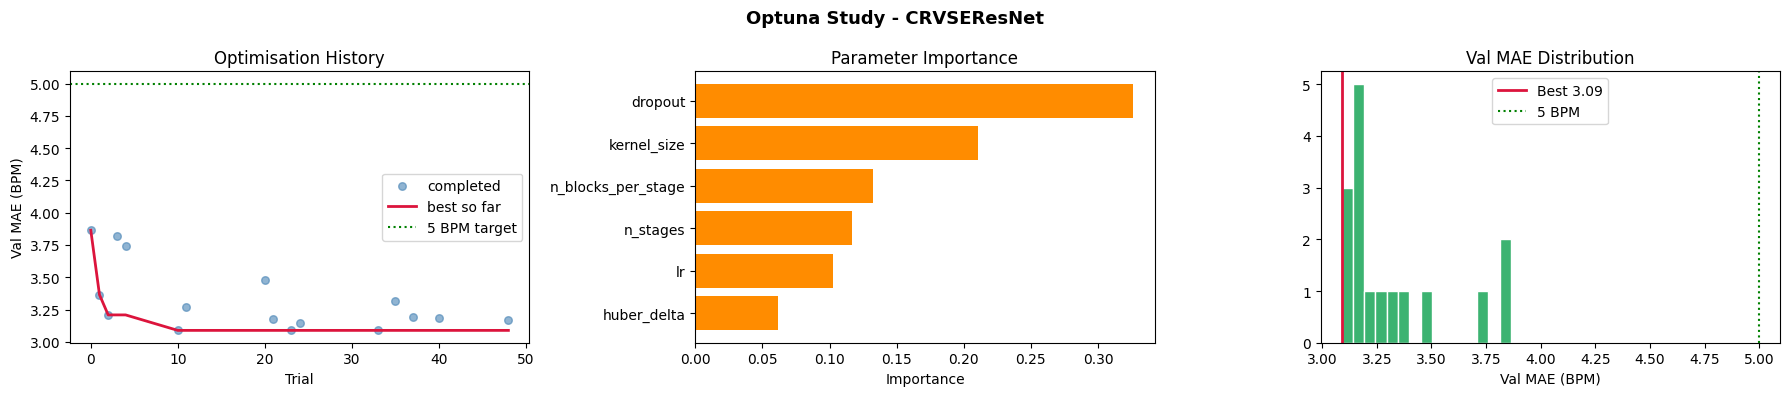

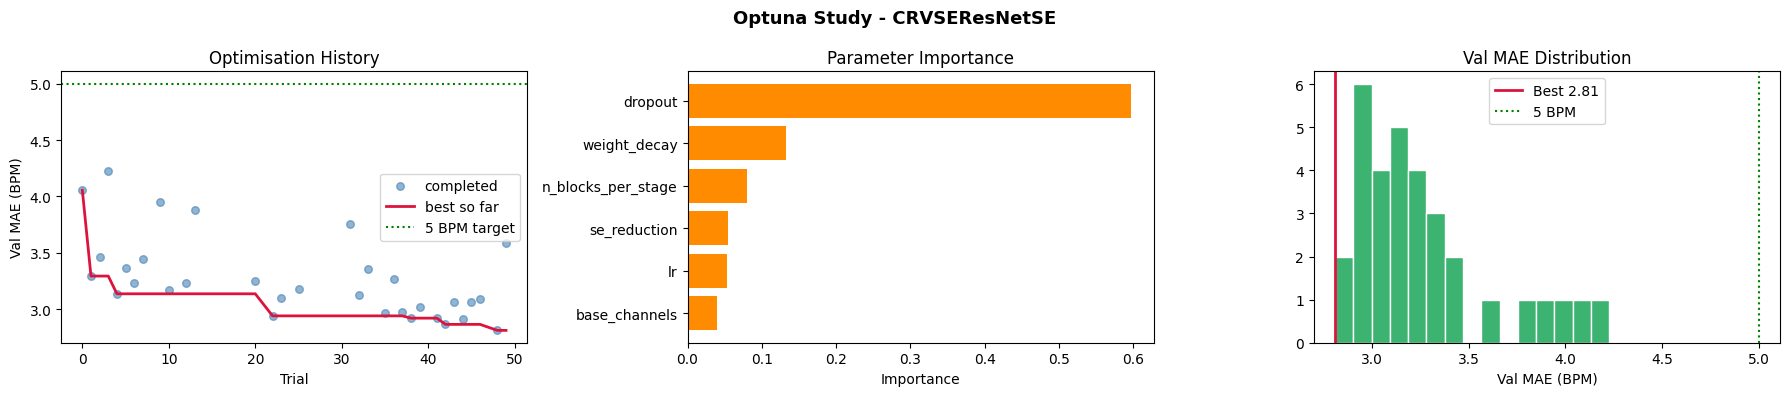

In [16]:
def plot_study(study: optuna.Study, arch_name: str) -> None:
    trials = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
    numbers = [t.number for t in trials]
    val_maes = [t.value  for t in trials]
    best_curve = np.minimum.accumulate([t.value for t in sorted(trials, key=lambda t: t.number)])

    fig,axes = plt.subplots(1, 3, figsize=(18, 4))
    fig.suptitle(f"Optuna Study - {arch_name}", fontweight="bold", fontsize=13)

    axes[0].scatter(numbers, val_maes, alpha=0.6, s=30, color="steelblue", label="completed")
    axes[0].plot(sorted(numbers), best_curve, color="crimson", linewidth=2, label="best so far")
    axes[0].axhline(5.0, color="green", linestyle=":", label="5 BPM target")
    axes[0].set_xlabel("Trial"); axes[0].set_ylabel("Val MAE (BPM)")
    axes[0].set_title("Optimisation History"); axes[0].legend()

    try:
        importances = optuna.importance.get_param_importances(study)
        top = list(importances.items())[:6]
        params, imps = zip(*top)
        axes[1].barh(params, imps, color="darkorange")
        axes[1].set_xlabel("Importance"); axes[1].set_title("Parameter Importance")
        axes[1].invert_yaxis()
    except Exception:
        axes[1].text(0.5, 0.5, "Not available", ha="center", va="center", transform=axes[1].transAxes)

    axes[2].hist(val_maes, bins=15, color="mediumseagreen", edgecolor="white")
    axes[2].axvline(study.best_value, color="crimson", linewidth=2, label=f"Best {study.best_value:.2f}")
    axes[2].axvline(5.0, color="green", linestyle=":", label="5 BPM")
    axes[2].set_xlabel("Val MAE (BPM)"); axes[2].set_title("Val MAE Distribution")
    axes[2].legend()

    plt.tight_layout()
    plt.savefig(f"optuna_{arch_name.lower().replace(' ', '_')}.png",
                dpi=150, bbox_inches="tight")
    plt.show()


# Plot both ResNet studies
for arch_name, study in [
    ("CRVSEResNet", study_resnet),
    ("CRVSEResNetSE", study_resnet_se),
]:
    plot_study(study ,arch_name)

## 12. Train model on best configuration (training on full train + val, evaluation on test set)

In [17]:
def retrain_best(name: str, model_class: type, study: optuna.Study, arch_keys: list[str], save_path: str) -> nn.Module:
    """
    Retrain best trial config on train+val, evaluate on test.
    Returns the trained model.
    """
    p = study.best_params
    best_n_epochs = study.best_trial.last_step

    print(f"\n{'='*50}")
    print(f"Retraining {name}")
    print(f"Best trial epoch : {best_n_epochs}")
    print(f"{'='*50}")

    arch_kwargs = {key: p[key] for key in arch_keys if key in p}

    model = model_class(
        in_channels = 1,
        dropout = p["dropout"],
        hr_min = HR_MIN,
        hr_max = HR_MAX,
        **arch_kwargs,
    ).to(DEVICE)

    full_ds = CRVSEDataset(all_samples, train_keys | val_keys)
    full_loader = DataLoader(
        full_ds, batch_size=BATCH_SIZE,
        shuffle=True, num_workers=2, pin_memory=True
    )

    loss_function = nn.HuberLoss(delta=p["huber_delta"])
    optimizer = AdamW(model.parameters(), lr=p["lr"], weight_decay=p["weight_decay"])
    scheduler = CosineAnnealingLR(optimizer, T_max=best_n_epochs, eta_min=p["lr"] / 100)

    epoch_bar = tqdm(range(1, best_n_epochs + 1), desc = f"Training {name}", unit = "epoch")
    for epoch in epoch_bar:
        model.train()
        total_loss = 0.0
        for signals, labels in full_loader:
            signals, labels = signals.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            preds = model(signals)
            loss  = loss_function(preds, labels)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total_loss += loss.item()
        scheduler.step()
        epoch_bar.set_postfix({"loss": f"{total_loss / len(full_loader):.3f}"})

    torch.save({
        "best_params" : p,
        "best_n_epochs" : best_n_epochs,
        "model_state" : model.state_dict(),
    }, save_path)
    print(f"Saved → {save_path}")

    return model



# Architecture keys per model 
RESNET_ARCH_KEYS = ["base_channels", "n_blocks_per_stage", "n_stages", "kernel_size"]
RESNET_SE_ARCH_KEYS = ["base_channels", "n_blocks_per_stage", "n_stages", "kernel_size", "se_reduction"]


# Retrain
model_resnet = retrain_best(
    "CRVSEResNet", CRVSEResNet,
    study_resnet, RESNET_ARCH_KEYS,
    "crvse_resnet_best.pt"
)
model_resnet_se = retrain_best(
    "CRVSEResNetSE", CRVSEResNetSE,
    study_resnet_se, RESNET_SE_ARCH_KEYS,
    "crvse_resnet_se_best.pt"
)


Retraining CRVSEResNet
Best trial epoch : 50
Dataset size: 8077 windows


Training CRVSEResNet: 100%|██████████| 50/50 [03:15<00:00,  3.90s/epoch, loss=16.867]


Saved → crvse_resnet_best.pt

Retraining CRVSEResNetSE
Best trial epoch : 50
Dataset size: 8077 windows


Training CRVSEResNetSE: 100%|██████████| 50/50 [05:46<00:00,  6.93s/epoch, loss=14.772]

Saved → crvse_resnet_se_best.pt


## 13. Full evaluation all 2 models

In [18]:
def collect_predictions(model: nn.Module, loader: DataLoader, ds: CRVSEDataset) -> tuple[np.ndarray, np.ndarray, list[str], list[str]]:
    """Collect predictions, labels, subject_ids, dataset_ids from a loader."""
    model.eval()
    preds_list, labels_list = [], []

    with torch.inference_mode():
        for signals, labels in loader:
            preds = model(signals.to(DEVICE)).cpu().numpy()
            preds_list.extend(preds.tolist())
            labels_list.extend(labels.numpy().tolist())

    subject_ids = [ds.items[i]["subject_key"] for i in range(len(ds))]
    dataset_ids = [ds.items[i]["dataset"] for i in range(len(ds))]

    return (
        np.array(preds_list,  dtype=np.float32),
        np.array(labels_list, dtype=np.float32),
        subject_ids,
        dataset_ids,
    )


results = {}

for name, model in [("CRVSEResNet",   model_resnet), ("CRVSEResNetSE", model_resnet_se)]:
    preds, labels, subj_ids, ds_ids = collect_predictions(model, test_loader, test_ds)
    full_evaluation(preds = preds, labels = labels, subject_ids = subj_ids, dataset_ids = ds_ids, model_name = name)
    # Store for comparison table
    results[name] = {
        "preds" : preds,
        "labels" : labels,
        "subj" : subj_ids,
        "ds" : ds_ids,
    }


FULL EVALUATION - CRVSEResNet

Window-level (n=1424 windows):
MAE : 2.99 BPM
RMSE : 4.77 BPM
MAPE : 3.85 %
Pearson r : 0.9412  (p=0.0000)
R² : 0.8817
BA bias : -0.80 BPM
BA LoA : [-10.01, 8.41] BPM

|error| <  5 BPM : 84.3% of windows
|error| < 10 BPM : 94.5% of windows
|error| < 15 BPM : 98.0% of windows

Subject-level metrics (n=29 subjects):
MAE : 2.24 BPM
RMSE : 2.92 BPM
r : 0.9848
BA bias: -0.65 BPM
BA LoA : [-6.24, 4.93] BPM

Per-dataset breakdown:
Dataset             n      MAE     RMSE        r
----------------------------------------------
mcd_rppg         1174     2.43     3.73   0.9112
ubfc_phys         175     5.40     7.23   0.6877
ubfc_rppg          75     6.08     9.56   0.7304

HR-stratified metrics:
Range                      n      MAE     RMSE
----------------------------------------------
bradycardia/low          284     2.68     4.31
normal low               833     2.53     4.28
normal high              178     4.52     6.24
tachycardia/exercise     129     4.46 

## 14. Round 4 internal comparison table

In [19]:
def round4_comparison(results: dict) -> str:
    """
    Print Round 4 comparison table and return name of best model.
    """
    print("\n" + "=" * 65)
    print("ROUND 4 - ResNet VARIANTS COMPARISON")
    print("=" * 65)

    rows = {}
    for name, r in results.items():
        diff = r["preds"] - r["labels"]
        mae = float(np.mean(np.abs(diff)))
        rmse = float(np.sqrt(np.mean(diff ** 2)))
        pearr,_ = stats.pearsonr(r["preds"], r["labels"])
        r2 = float(1 - np.sum(diff**2) / np.sum((r["labels"] - r["labels"].mean())**2))
        ba_bias = float(diff.mean())
        ba_sd = float(diff.std())
        cov5 = float(np.mean(np.abs(diff) < 5) * 100)
        rows[name] = dict(mae=mae, rmse=rmse, r=pearr, r2=r2, ba_bias=ba_bias, ba_sd=ba_sd, cov5=cov5)

    # Print table
    hdr = f"{'Model':<25} {'MAE':>6} {'RMSE':>6} {'r':>7} {'R²':>7} {'BA bias':>8} {'<5BPM%':>8}"
    print(hdr)
    print("  " + "-" * 65)
    for name, m in rows.items():
        print(f"{name:<25} {m['mae']:>6.2f} {m['rmse']:>6.2f} {m['r']:>7.4f} {m['r2']:>7.4f}{m['ba_bias']:>8.2f} {m['cov5']:>7.1f}%")

    best_name = min(rows, key=lambda n: rows[n]["mae"])
    print(f"\nBest Round 4 model : {best_name} (MAE {rows[best_name]['mae']:.2f} BPM)")
    return best_name

best_r4 = round4_comparison(results)


ROUND 4 - ResNet VARIANTS COMPARISON
Model                        MAE   RMSE       r      R²  BA bias   <5BPM%
  -----------------------------------------------------------------
CRVSEResNet                 2.99   4.77  0.9412  0.8817   -0.80    84.3%
CRVSEResNetSE               2.82   4.30  0.9573  0.9037   -1.49    88.6%

Best Round 4 model : CRVSEResNetSE (MAE 2.82 BPM)
